# Puzzle block signatures

Explore **non-isomorphic puzzle classes**, counted once each. Use the **v2/.venv** kernel and run the cells in order. No enumeration or graph search is needed: the saved database contains the complete results.

Change `COHORT` below to choose:

- `"filtered"`: **4,857** classes, identifying mirrors and excluding permanently frozen or one-axis puzzles.
- `"all"`: **7,073** classes, retaining mirror pairs and dead ends.
- `"mirror"`: 4,860 classes, merging mirrors and retaining dead ends.
- `"mobile"`: 7,070 classes, removing dead ends and retaining mirror pairs.

All cohorts exclude invisible core bonds and **include every implicit adjacent bond**. Signatures describe these effective blocks, rather than a particular glue recipe that may contain further implicit connections.


In [1]:
import csv
import html
import sys
from pathlib import Path

import bce_v2 as c
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

%matplotlib inline

COHORT = "filtered"  # Change to "all" to retain mirrors and dead ends.
root = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "v2/enumeration-results/2026-10-07-shell-signatures.sqlite3").is_file())
results = root / "v2/enumeration-results"
database = results / "2026-10-07-shell-signatures.sqlite3"
if "atlas" in globals():
    atlas.close()
atlas = c.PuzzleAtlas(database, cohort=COHORT)
print("Kernel:", sys.executable)
print(f"Cohort: {atlas.cohort}; {len(atlas):,} puzzle classes")


Kernel: /home/ladislav/prj/nonvl/bandaged-cube-explorer/v2/.venv/bin/python
Cohort: filtered; 4,857 puzzle classes


In [2]:
def table(rows, columns=None, *, max_height=600):
    """Display every row in a scrollable table without requiring pandas."""
    rows = list(rows)
    if not rows:
        display(Markdown("No matches."))
        return
    columns = columns or list(rows[0])
    heading = "".join(f"<th>{html.escape(str(column))}</th>" for column in columns)
    body = "".join("<tr>" + "".join(
        f"<td>{html.escape(str(row[column]))}</td>" for column in columns) + "</tr>"
        for row in rows)
    display(HTML(f'<div style="max-height:{max_height}px;overflow:auto">'
                 f'<table><thead><tr>{heading}</tr></thead><tbody>{body}</tbody></table></div>'
                 f'<p>{len(rows):,} rows shown; scroll to see all rows.</p>'))


def gallery(rows, *, limit=6):
    rows = list(rows)[:limit]
    if not rows:
        return
    visible_faces = ({cell for cell in range(27) if cell // 9 == 0},
                     {cell for cell in range(27) if (cell // 3) % 3 == 2},
                     {cell for cell in range(27) if cell % 3 == 2})

    def visible_bonds(shape):
        return sum(shape[cell] == shape[cell + stride]
                   for face in visible_faces for cell in face for stride in (1, 3, 9)
                   if (cell // stride) % 3 < 2 and cell + stride in face)

    shapes = [max((atlas.shape(row["id"]).rotated(rotation) for rotation in range(24)),
                  key=visible_bonds) for row in rows]
    figure = c.draw_cubes(shapes, ncol=3, size=3)
    figure.set_size_inches(9 if len(rows) >= 3 else 3 * len(rows), 3.5 * ((len(rows) + 2) // 3))
    figure.subplots_adjust(wspace=0.08, hspace=0.35, top=0.9, bottom=0.02)
    for axis, row in zip(figure.axes, rows):
        axis.set_title(row["id"] + "\n" + row["signature"], fontsize=9)
    plt.show()


## What a signature means

Dimensions are sorted longest first: `221` means 2×2×1 in any orientation. `211` splits into **Clock** (contains a face center) and **Pair** (contains no face center). The name **BigBlock** is an alias for `322`; signatures use the numeric identifier.

Larger boxes appear first, ordered by bounding-box volume, with dimensions breaking ties. A count of one has no prefix: `2x221 Clock 2xPair`. `111` cubies are omitted from the label; the unbandaged puzzle is labeled `111 only`.

A block is rigid under legal turns, so its sorted dimensions, cubie kinds, and center membership remain unchanged. Whole-cube rotations and mirrors preserve them too. Signatures are therefore properties of a class, though many classes can have the same signature.

**The virtual core matters.** A shell `222` has seven physical cubies. A `221` can have four cubies or three with a core hole. This coarse dimension signature does not always determine the remaining `111` count. The database stores the exact count separately, and stores each block's physical cubies, corners, edges, centers, and core-hole flag for finer queries. `singletons_min` and `singletons_max` make this distinction visible in grouped results.

Galleries show a whole-cube rotation chosen to expose fused faces; captions retain the original stable puzzle IDs.


In [3]:
catalogue = []
for block in c.BLOCK_TYPES:
    sizes = atlas.query("SELECT DISTINCT cubies FROM blocks WHERE block_type = ? ORDER BY cubies",
                        (block.code,))
    catalogue.append({"type": block.code, "dimensions": "x".join(map(str, block.dimensions)),
                      "name": block.name, "shell cubies observed": ", ".join(str(row["cubies"]) for row in sizes),
                      "description": block.description})
table(catalogue)
print("Formatting example:", c.format_signature({"Pair": 2, "221": 2, "Clock": 1}))


type,dimensions,name,shell cubies observed,description
333,3x3x3,Fused cube,26,The whole cube shell
332,3x3x2,Two layers,17,Two full layers fused together
322,3x2x2,BigBlock,11,A 3×2×2 bounding box
331,3x3x1,Full layer,"8, 9",One full layer fused together
222,2x2x2,222,7,A 2×2×2 bounding box
321,3x2x1,321,"5, 6",A 3×2×1 rectangle
221,2x2x1,221,"3, 4",A 2×2×1 rectangle
311,3x1x1,311,3,A straight three-cell bar
Clock,2x1x1,Clock,2,A 211 block containing a face center
Pair,2x1x1,Pair,2,A 211 block without a face center


Formatting example: 2x221 Clock 2xPair


## Compare the atlases

Mirror merging changes the number of puzzles for a signature, but never creates a new signature: mirror partners have the same inventories. The agreed dead-end filter removes three signatures, corresponding to the fused shell and the two slab puzzles. The fully fused `333`, `332`, and `331` types consequently do not occur in the filtered cohort.


In [4]:
comparison = []
for cohort in c.PuzzleAtlas.COHORTS:
    with c.PuzzleAtlas(database, cohort=cohort) as other:
        maximum, maximal = other.maximum("211", only=("211",))
        comparison.append({"cohort": cohort, "puzzles": len(other),
                           "signatures": len(other.signature_counts()),
                           "contain 222": len(other.containing("222")),
                           "maximum 211-only blocks": maximum,
                           "puzzles reaching maximum": len(maximal)})
table(comparison)


cohort,puzzles,signatures,contain 222,maximum 211-only blocks,puzzles reaching maximum
all,7073,931,339,12,2
mirror,4860,931,238,12,1
mobile,7070,928,339,12,2
filtered,4857,928,238,12,1


## How many puzzles contain a 222 block?

`containing` counts classes with **at least one** matching block, rather than counting block occurrences. Change `BLOCK` and `AT_LEAST` to ask other questions. Numeric `211` matches both Clocks and Pairs; `"Clock"` and `"Pair"` query them separately.


238 of 4,857 classes contain at least 1 222 block(s).


id,signature,singletons,fixed_frame_vertices,ever_axes
000450010c000b,222,19,1,3
000450010c000f,222 Pair,17,18,3
000450010c002b,222 Clock,17,4,3
000450010c002f,222 Clock Pair,15,62,3
000450010c004f,222 2xPair,15,129,3
000450010c006f,222 Clock 2xPair,13,370,3
000450010c00ab,222 2xClock,15,15,3
000450010c00af,222 2xClock Pair,13,196,3
000450010c00ef,222 2xClock 2xPair,11,970,3
000450010c014f,222 3xPair,13,450,3


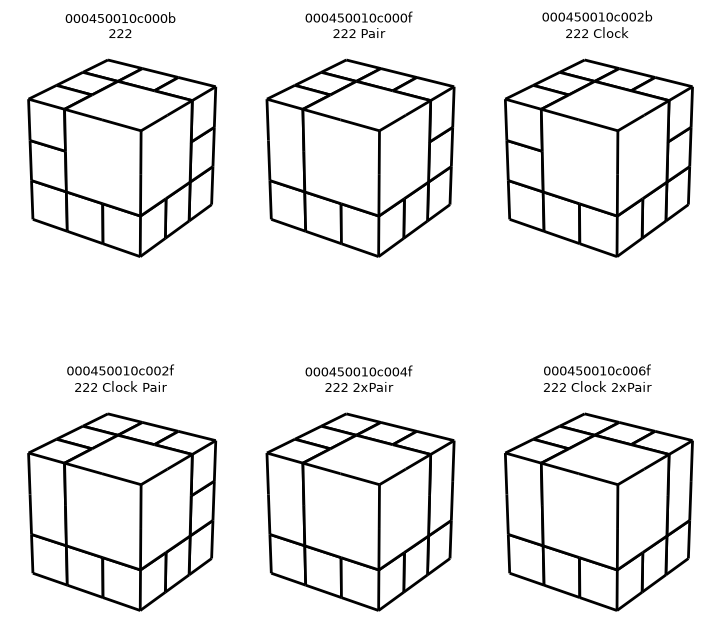

In [5]:
BLOCK = "222"
AT_LEAST = 1
matching = atlas.containing(BLOCK, at_least=AT_LEAST)
print(f"{len(matching):,} of {len(atlas):,} classes contain at least {AT_LEAST} {BLOCK} block(s).")
table(matching[:12], ["id", "signature", "singletons", "fixed_frame_vertices", "ever_axes"])
gallery(matching)


## How common is each block type?

This distinguishes puzzle counts from total block occurrences. `max_per_puzzle` gives the largest multiplicity of that type in the selected cohort, allowing other block types as well.


In [6]:
prevalence = atlas.query(f"""
    WITH per_puzzle AS (
        SELECT b.block_type, b.puzzle_id, COUNT(*) AS blocks
        FROM blocks b JOIN puzzles_{atlas.cohort} p ON p.id = b.puzzle_id
        GROUP BY b.block_type, b.puzzle_id
    )
    SELECT t.code AS type, COUNT(*) AS puzzles_containing,
           SUM(q.blocks) AS total_blocks, MAX(q.blocks) AS max_per_puzzle
    FROM per_puzzle q JOIN block_types t ON t.code = q.block_type
    GROUP BY t.code ORDER BY t.display_order
""")
table(prevalence)


type,puzzles_containing,total_blocks,max_per_puzzle
322,77,77,1
222,238,238,1
321,1676,1926,4
221,3101,4968,5
311,3476,5898,8
Clock,3723,7109,5
Pair,4042,10918,7
111,4818,40920,26


## Maximum number of 211 blocks, with only 111 remaining

This asks for the **global maximum number of dominoes** among classes with no larger blocks. Both Clock and Pair count as `211`. It does not ask for an arrangement to which no further domino can be added.

Twelve is also a geometric upper bound: the shell has twelve edge cubies, and every adjacent 211 pairs one edge with a corner or a center. There are fourteen corners/centers in total, leaving two singletons when all twelve edges are paired.


Maximum: 12 dominoes; 1 puzzle class(es).


id,signature,singletons,block_count,mirror_id
0000100071df00,5xClock 7xPair,2,12,0000100073de00


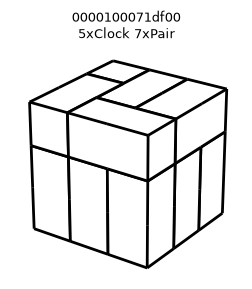

In [7]:
maximum, maximal_domino_puzzles = atlas.maximum("211", only=("211",))
print(f"Maximum: {maximum} dominoes; {len(maximal_domino_puzzles)} puzzle class(es).")
table(maximal_domino_puzzles, ["id", "signature", "singletons", "block_count", "mirror_id"])
gallery(maximal_domino_puzzles)


The two maximum-domino classes in the full atlas are a mirror pair. Their signature is `5xClock 7xPair`, with two singleton cubies. Additional restrictions are easy to express:


In [8]:
restrictions = []
for block, allowed in (("Pair", ("Pair",)), ("Clock", ("Clock",)), ("Pair", ("211",))):
    maximum, matches = atlas.maximum(block, only=allowed)
    restrictions.append({"maximize": block, "allowed nonsingletons": ", ".join(allowed),
                         "maximum": maximum, "puzzles": len(matches)})
table(restrictions)


maximize,allowed nonsingletons,maximum,puzzles
Pair,Pair,7,1
Clock,Clock,5,1
Pair,211,7,8


## Exact signatures and combinations

The following query asks for exactly two 221 blocks, one Clock, and two Pairs, with the remaining physical cubies singleton. Change the dictionary to explore another inventory. Different geometries may have the same signature.


2x221 Clock 2xPair: 7 classes


id,signature,singletons,fixed_frame_vertices,ever_axes
000000010c006f,2x221 Clock 2xPair,13,1244,3
000000010c00cf,2x221 Clock 2xPair,13,1140,3
0000000514016f,2x221 Clock 2xPair,12,2356,3
0000400410006f,2x221 Clock 2xPair,13,1089,3
0000408410006d,2x221 Clock 2xPair,13,1026,3
000050041c01e4,2x221 Clock 2xPair,12,1834,3
000050041c1164,2x221 Clock 2xPair,12,2074,3


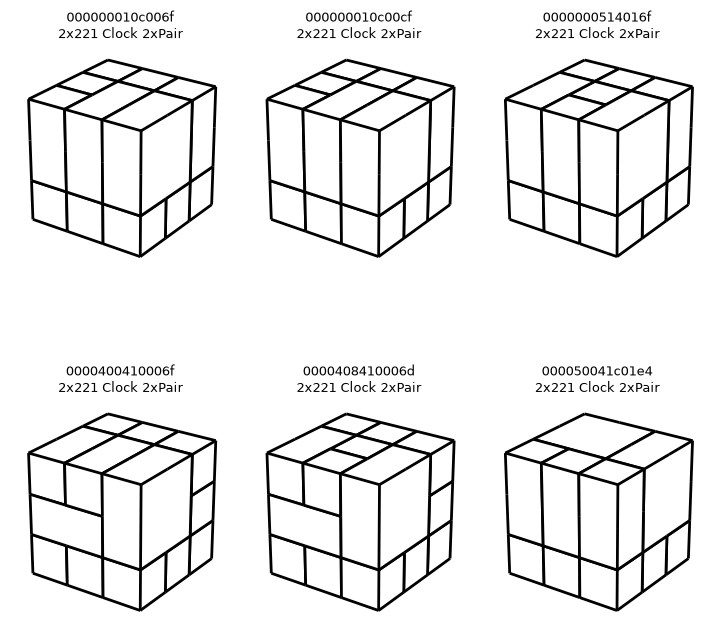

In [9]:
wanted = {"221": 2, "Clock": 1, "Pair": 2}
wanted_text = c.format_signature(wanted)
exact = atlas.select(signature=wanted_text)
print(f"{wanted_text}: {len(exact):,} classes")
table(exact[:12], ["id", "signature", "singletons", "fixed_frame_vertices", "ever_axes"])
gallery(exact)


In [10]:
# Combine minimum counts with an allowed inventory.
combined = atlas.select(contains={"Clock": 2, "Pair": 2}, only=("211",))
print(f"Domino-only classes with at least two Clocks and two Pairs: {len(combined):,}")
table(combined[:12], ["id", "signature", "singletons"])


Domino-only classes with at least two Clocks and two Pairs: 41


id,signature,singletons
0000000000000f,2xClock 2xPair,18
0000000000002d,2xClock 2xPair,18
0000000000002f,3xClock 2xPair,16
0000000000004f,2xClock 3xPair,16
0000000000006d,2xClock 3xPair,16
0000000000006f,3xClock 3xPair,14
000000000000af,4xClock 2xPair,14
000000000000ef,4xClock 3xPair,12
0000000000014f,2xClock 4xPair,14
0000000000016d,2xClock 4xPair,14


## Every signature and its number of puzzle classes

**Every row** for the selected cohort is shown below, sorted by puzzle count. Each signature itself lists blocks largest first. Scroll through the table or search this notebook for a signature.

The saved `2026-10-07-shell-signatures.csv` also lists all 931 signatures with counts for all four cohorts. It can be opened in a spreadsheet without running this notebook. Counts in each cohort sum to its complete puzzle total.


In [11]:
signatures = atlas.signature_counts()
assert sum(row["puzzles"] for row in signatures) == len(atlas)
print(f"{len(signatures):,} distinct signatures covering {len(atlas):,} classes.")
table(signatures, max_height=750)
print("Full four-cohort CSV:", results / "2026-10-07-shell-signatures.csv")


928 distinct signatures covering 4,857 classes.


signature,puzzles,singletons_min,singletons_max
221 2x311 2xClock 2xPair,40,8,9
2x221 311 2xClock 4xPair,33,3,4
221 2x311 Clock 2xPair,32,10,11
2x221 311 2xClock 3xPair,32,5,6
221 2x311 3xClock 2xPair,30,6,7
2x221 2x311 Clock 2xPair,28,6,7
221 2x311 2xClock Pair,26,10,11
2x221 2x311 2xClock 2xPair,26,4,5
321 221 311 Clock 2xPair,26,7,8
2x221 2x311 Clock Pair,24,8,9


Full four-cohort CSV: /home/ladislav/prj/nonvl/bandaged-cube-explorer/v2/enumeration-results/2026-10-07-shell-signatures.csv


## Which signatures occur in the most puzzles?

A signature forgets how the blocks are arranged. This table compares the number of classes and the range of shape-component sizes for the most frequent inventories. `fixed_frame_vertices` describes bandage shapes, not the much larger colored-state graph.


In [12]:
view = "puzzles_" + atlas.cohort  # cohort is validated by PuzzleAtlas
popular = atlas.query(f"""
    SELECT signature, COUNT(*) AS puzzles,
           MIN(fixed_frame_vertices) AS smallest_shape_component,
           MAX(fixed_frame_vertices) AS largest_shape_component
    FROM {view}
    GROUP BY signature
    ORDER BY puzzles DESC, signature LIMIT 15
""")
table(popular)


signature,puzzles,smallest_shape_component,largest_shape_component
221 2x311 2xClock 2xPair,40,21,4336
2x221 311 2xClock 4xPair,33,44,1178
221 2x311 Clock 2xPair,32,25,2614
2x221 311 2xClock 3xPair,32,46,5502
221 2x311 3xClock 2xPair,30,36,5992
2x221 2x311 Clock 2xPair,28,27,1513
221 2x311 2xClock Pair,26,64,2104
2x221 2x311 2xClock 2xPair,26,48,1036
321 221 311 Clock 2xPair,26,69,684
2x221 2x311 Clock Pair,24,34,744


## Refine the dimensions with physical cubie information

This SQL query distinguishes the two shell footprints of a 221. Each row counts **puzzles containing** that footprint, rather than counting occurrences. The full `block_inventory` view also exposes dimensions and the BigBlock alias for custom queries.


In [13]:
refined = atlas.query(f"""
    SELECT b.block_type, b.cubies, b.corners, b.edges, b.centers,
           b.core_hole, COUNT(DISTINCT b.puzzle_id) AS puzzles
    FROM blocks b JOIN {view} p ON p.id = b.puzzle_id
    WHERE b.block_type = ?
    GROUP BY b.block_type, b.cubies, b.corners, b.edges, b.centers, b.core_hole
    ORDER BY b.cubies DESC
""", ("221",))
table(refined)
ambiguous = [row for row in signatures if row["singletons_min"] != row["singletons_max"]]
print(f"{len(ambiguous):,} dimension signatures have more than one possible singleton count.")
table(ambiguous[:12])


block_type,cubies,corners,edges,centers,core_hole,puzzles
221,4,1,2,1,0,2511
221,3,0,1,2,1,1456


314 dimension signatures have more than one possible singleton count.


signature,puzzles,singletons_min,singletons_max
221 2x311 2xClock 2xPair,40,8,9
2x221 311 2xClock 4xPair,33,3,4
221 2x311 Clock 2xPair,32,10,11
2x221 311 2xClock 3xPair,32,5,6
221 2x311 3xClock 2xPair,30,6,7
2x221 2x311 Clock 2xPair,28,6,7
221 2x311 2xClock Pair,26,10,11
2x221 2x311 2xClock 2xPair,26,4,5
321 221 311 Clock 2xPair,26,7,8
2x221 2x311 Clock Pair,24,8,9


The coarse label deliberately groups these physical variants. If singleton counts or cubie-kind composition should be part of the signature, both refinements can be counted directly:


In [14]:
refined_totals = atlas.query(f"""
    SELECT
        (SELECT COUNT(DISTINCT signature) FROM {view}) AS dimension_signatures,
        (SELECT COUNT(*) FROM (SELECT 1 FROM {view} GROUP BY signature, singletons))
            AS including_singleton_count,
        (SELECT COUNT(DISTINCT detailed_signature) FROM {view}) AS including_cubie_kinds
""")
table(refined_totals)


dimension_signatures,including_singleton_count,including_cubie_kinds
928,1242,1732


## Questions to explore next

- **Placement versus inventory:** which signature has the most distinct puzzles, and can their arrangements be classified into useful geometric families?
- **Mobility within a signature:** why can identical block counts give very different reachable shape counts? Which inventories allow all three axes, and which require a long unlocking sequence?
- **Chirality:** which signatures contain only self-mirror puzzles, only chiral pairs, or both? Can a small arrangement explain the difference?
- **Physical refinements:** should center/corner/edge membership and core-hole footprints become named subtypes for 221, 311, and 321, as they already are for 211?
- **Minimal bandaging:** how many effective blocks or bonds are needed to force a particular mobility restriction? Compare explicit glue recipes with their implicit closure.
- **Packing and feasibility:** can impossible signatures be ruled out from cubie counts or adjacency constraints before classifying their arrangements?
- **Colored complexity:** do puzzles with the same block signature have very different colored-state group sizes or solving difficulty? This needs further analysis beyond shape-component size.

The coarse signature is intentionally an inventory, not a complete isomorphism invariant. All queries here continue to count full puzzle classes from the certified atlas.
